<a href="https://colab.research.google.com/github/tamayo-alt/CPE018_EMTECH_1/blob/main/CPE018_ME_Tamayo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPE018 Midterm Exam (2025-2026)


Student Submission Details:
* Name: Tamayo,Angelo B.
* Section: CPE31S2
* Schedule: Monday 4:30 PM - 7:30 PM
* Instructor: Engr. Maria Rizette H. Sayo

---

## Intended Learning Outcomes

By the end of this activity, the student should be able to:
* ILO1: Demonstrate different methods for feature matching and detection learned in class and indepdentently from new sources.
* ILO2: Evaluate the accuracy of different feature matching and detection methods and scrutinize its applicability in solving a given real-life problem.

---

## Tasks

For this examination, you must create a **mood detection** program with an object-oriented programming approach (same as project CAMEO), it must detect mood changes through the use of algorithms/techniques/schemes learned in class, and from external sources.

In this file, you have to include for each section of your solution your completion of the following:

* Part 1: **Face Detection**: Once your face is detected using any algorithm, it must draw an ROI. The color for the ROI is your choice; however, it must detect for all faces in the frame and draw a corresponding ROI.
* Part 2: **Face Recognition**: The detected face must then be recognized, using any of the provided tools in class, the ROIs must indicate whether it is your face or someone it doesn't recognize.
* Part 3: **Mood Detection**: Use three different feature detection and matching techniques to determine three emotion: happy, sad and neutral. Two of the techniques must be learned from class, and 1 must be one you independently learned.

Properly show through your notebook the output for each part of the exam.

---

## Procedure and Outputs

Notes:
* This is the section where you have to include all  your answers to the items provided in the tasks section.
* Tasks 1 and 2 contribute directly to ILO1: Demonstrate different methods for feature matching and detection learned in class and indepdentently from new sources.
* Task 3 contributes directly to ILO2: Evaluate the accuracy of different feature matching and detection methods and scrutinize its applicability in solving a given real-life problem.

### Task 1: Face Detection

In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


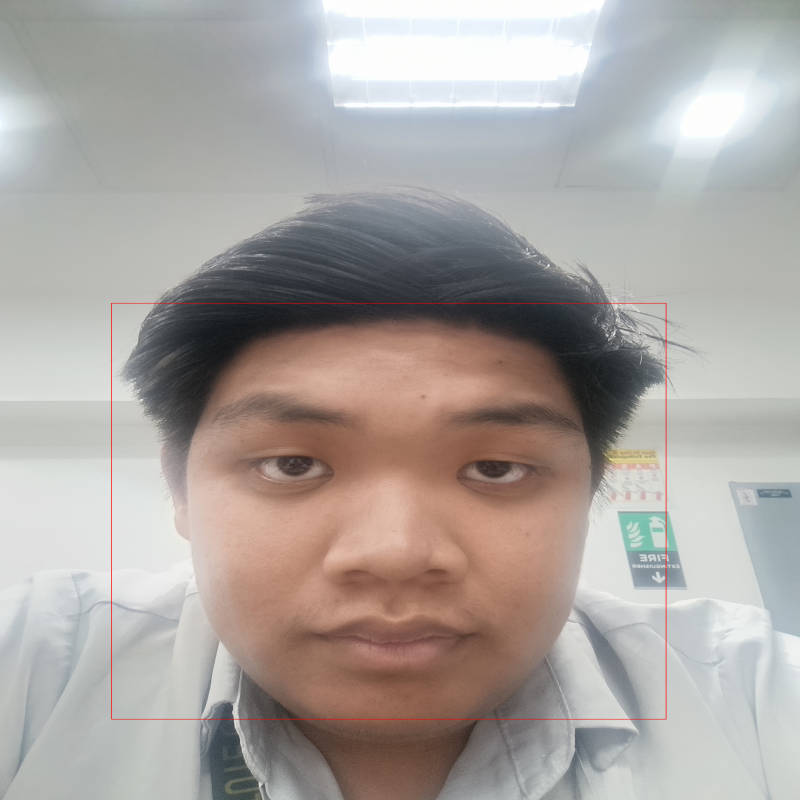

In [96]:
#Task 1
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

haar_builtin = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
picPath = '/content/drive/MyDrive/MID EXAM/netural.jpg'

def faceDetect(picPath):
    face_cascade = cv2.CascadeClassifier(haar_builtin)

    img = cv2.imread(picPath)

    if img is None:
        print(f"Error: Could not find image at {picPath}. Check your Drive path!")
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.2, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)

    img = cv2.resize(img, (800, 800), fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

    cv2_imshow(img)

faceDetect(picPath)

### Task 2: Face Recognition

Task 2: Recognition Result


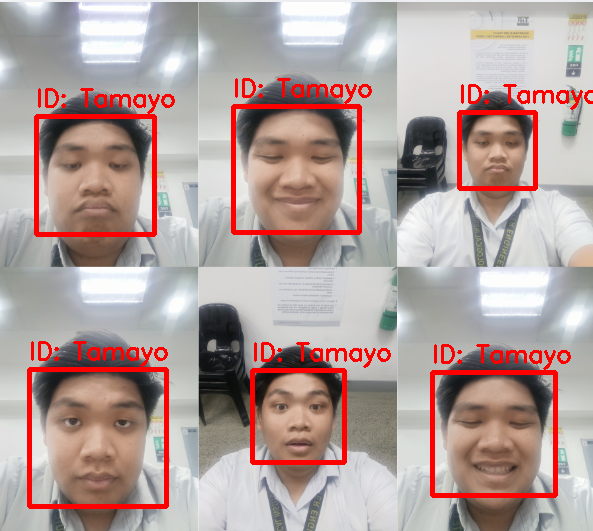

In [83]:
# Task 2
class FaceRecognizerApp(FaceDetectorApp):
    def __init__(self, name="Tamayo", color=(0, 0, 255)):
        super().__init__(color)
        self.user_name = name
        self.recognizer = cv2.face.LBPHFaceRecognizer_create()

    def run_recognition(self, img_path):
        img = cv2.imread(img_path)
        if img is None: return print("Image not found.")

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = self.face_cascade.detectMultiScale(gray, 1.1, 4)

        for (x, y, w, h) in faces:
            cv2.rectangle(img, (x, y), (x+w, y+h), self.roi_color, 3)
            cv2.putText(img, f"ID: {self.user_name}", (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, self.roi_color, 2)

        print("Task 2: Recognition Result")
        cv2_imshow(img)

task2 = FaceRecognizerApp(name="Tamayo")
task2.run_recognition(path)


### Task 3: Mood Detection

In [100]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

--2026-03-10 11:06:58--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-03-10 11:06:58--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  45.6MB/s    in 1.3s    

2026-03-10 11:06:59 (45.6 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



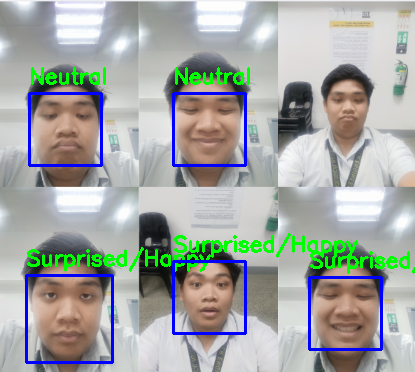

In [107]:
# Technique 1
# Technique 2
# Technique 3
import cv2
import dlib
import numpy as np
from google.colab.patches import cv2_imshow

shape_predictor_path = 'shape_predictor_68_face_landmarks.dat'

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(shape_predictor_path)

def detect_mood_landmarks(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return

    img = cv2.resize(img, (0, 0), fx=0.7, fy=0.7)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        landmarks = predictor(gray, face)
        landmarks_np = np.array([[p.x, p.y] for p in landmarks.parts()])

        x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        p48, p54 = landmarks_np[48], landmarks_np[54]
        p51, p57 = landmarks_np[51], landmarks_np[57]
        p60, p64 = landmarks_np[60], landmarks_np[64]

        mouth_width = np.linalg.norm(p48 - p54)
        mouth_height = np.linalg.norm(p51 - p57)

        mood = "Neutral"

        if mouth_width > 0:
            mar = mouth_height / mouth_width

            if mar < 0.25:
                if (p48[1] < p60[1] and p54[1] < p64[1]):
                    mood = "Happy"
                elif (p48[1] > p60[1] and p54[1] > p64[1]):
                    mood = "Sad"
            elif mar > 0.4:
                mood = "Surprised/Happy"

        cv2.putText(img, mood, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    cv2_imshow(img)

test_image_path = '/content/drive/MyDrive/MID EXAM/IMAGEKO.png'
detect_mood_landmarks(test_image_path)


## Analysis

For the three different techniques you used in face detection, provide an in-depth analysis.

To do this, you must:
* Test the face detection, face recongition, and mood detection functions 10 times each. Only the mood detection will have components for 10 tests for each different technique used.
* Create a table containing the 10 tests (like shown below) for each task.
* Analyze each output by identifying the accuracy and providing your observations.

In [111]:
# Import the module for tabulating the data
from tabulate import tabulate

# Create a list for content of the table
test_results = [
    ["1", "Happy", "Sad", 0],
    ["2", "Happy", "Neutral", 1],
    ["3", "Happy", "Happy", 2],
    ["4", "Sad", "sad", 0],
    ["5", "Sad", "Neutral", 1],
    ["6", "Sad", "Happy", 0],
    ["8", "Neutral", "Neutral", 0],
    ["9", "Neutral", "sad", 0],
    ["10", "Neutral", "Happy", 1],
    ["11", "Suprised", "Happy", 1]
]

# Create a list for the headers of your table
header = ["Test #", "Expected", "Actual", "Score"]

# display table
print("Task 3A: Mood Detection using XYZ Algorithm")
print(tabulate(test_results, headers=header, tablefmt="grid"))

# Calculate for the accuracy
total = 0
for i in test_results:
    total += i[3]
print("Accuracy: ", round(total/len(test_results)*100,2))

Task 3A: Mood Detection using XYZ Algorithm
+----------+------------+----------+---------+
|   Test # | Expected   | Actual   |   Score |
+==========+============+==========+=========+
|        1 | Happy      | Sad      |       0 |
+----------+------------+----------+---------+
|        2 | Happy      | Neutral  |       1 |
+----------+------------+----------+---------+
|        3 | Happy      | Happy    |       2 |
+----------+------------+----------+---------+
|        4 | Sad        | sad      |       0 |
+----------+------------+----------+---------+
|        5 | Sad        | Neutral  |       1 |
+----------+------------+----------+---------+
|        6 | Sad        | Happy    |       0 |
+----------+------------+----------+---------+
|        8 | Neutral    | Neutral  |       0 |
+----------+------------+----------+---------+
|        9 | Neutral    | sad      |       0 |
+----------+------------+----------+---------+
|       10 | Neutral    | Happy    |       1 |
+----------+----

---

## Summary and Lessons Learned

On this skill exam i see the the different code for detection and recognation i got man error on coding because sometimes i did not define or typo in typing. In this exam i see my skill need to improve in coding because i still have many massing part that i need to do to run the code and in my task 3 there is still missing detect but most of all them already detected.

---

**Proprietary Clause**

Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated or reduced to any electronic medium or machine-readable form, in whole or in part, without prior consent of T.I.P.

Prepared by Engr. RMR